
MODULE 4 GROUP G14 - Summative Lab- Data Vine Analytics

DATA VINE ANALYTICS (WINE VARIETY CLASSIFICATION)

K-NEAREST NEIGHBORS WITH PCA AND HYPERPARAMETER TUNING.

Business context.

A premium wine distributor needs to automatically classify wines into their correct cultivar/variety based on chemical properties, to support inventory management and quality control. Approach.
a) Load and clean the Wine dataset 

b) Encode the target and standardize the numerical features 

c) Reduce dimensionality with PCA (retain 95% variance) 

d) Tune a k-NN classifier with GridSearchCV (k value + distance metric) 

e) Evaluate the final model and visualize the results for stakeholders




1.	IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)


2.	DATASET PREPARATION

a)	Load and Inspect the Wine Dataset.

The Wine dataset contains the results of a chemical analysis of wines grown in the same region of Italy, derived from three different cultivars. Each row is a wine sample, the Wine column is the cultivar label (1, 2, or 3) and the remaining 13 columns are chemical measurements.


In [2]:
wine = pd.read_csv("wine.csv")
print("Shape:", wine.shape)
wine.head()


Shape: (178, 14)


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
wine.info()


<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [4]:
print("Summary statistics:")
wine.describe().T


Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Wine,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic.acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Acl,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Mg,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid.phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanth,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


b)	Check for Missing Values and Duplicates

In [5]:
print("Missing values per column:")
print(wine.isnull().sum())

print("\nTotal missing values:", wine.isnull().sum().sum())
print("Duplicate rows:", wine.duplicated().sum())


Missing values per column:
Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

Total missing values: 0
Duplicate rows: 0


No missing values or duplicate records were found in the Wine dataset, so no imputation or row-dropping is required. The dataset is already numeric and well-formed, which is common for this classic benchmark dataset.

c)	Class Distribution

Class distribution (wine cultivar):
Wine
1    59
2    71
3    48
Name: count, dtype: int64


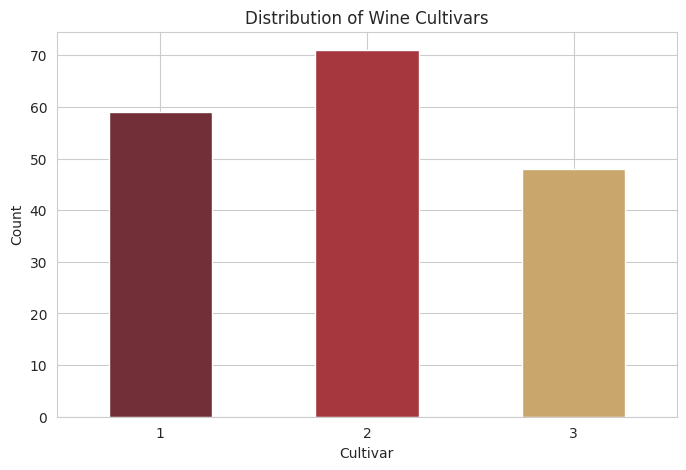

In [6]:
print("Class distribution (wine cultivar):")
print(wine["Wine"].value_counts().sort_index())

wine["Wine"].value_counts().sort_index().plot(kind="bar", color=["#722F37", "#A6373E", "#C9A66B"])
plt.title("Distribution of Wine Cultivars")
plt.xlabel("Cultivar")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


d)	Encode the Target Variable

The Wine column is already numeric (1, 2, 3), but per the task requirements, we explicitly convert the categorical cultivar labels into numeric class labels using `Label Encoder`, which also gives us a reusable mapping and guards against any dataset where labels are strings


In [7]:
le = LabelEncoder()
X = wine.drop(columns=["Wine"])
y_raw = wine["Wine"]
y = le.fit_transform(y_raw)

print("Original classes:", le.classes_)
print("Encoded classes:", np.unique(y))
print("Feature columns:", list(X.columns))


Original classes: [1 2 3]
Encoded classes: [0 1 2]
Feature columns: ['Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']


e)	Standardize the Numerical Features

k-NN is a distance-based algorithm, so features on larger scales (e.g. Proline, which is in the hundreds/thousands) would dominate the distance calculation over features like Ash (single digits) unless we standardize. We scale every feature to zero mean and unit variance.


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.describe().T[["mean", "std"]].round(3)


,mean,std
Alcohol,-0.0,1.003
Malic.acid,-0.0,1.003
Ash,-0.0,1.003
Acl,-0.0,1.003
Mg,-0.0,1.003
Phenols,0.0,1.003
Flavanoids,-0.0,1.003
Nonflavanoid.phenols,0.0,1.003
Proanth,-0.0,1.003
Color.int,0.0,1.003


3.	k-NN Classification with PCA and Hyperparameter Tuning.
  
a)	Train/Test Split
We hold out 25% of the data for testing, stratified on the target so all three cultivars are proportionally represented in both sets.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (133, 13)
Test shape: (45, 13)


b)	Dimensionality Reduction with PCA

We fit PCA on the standardized training features and keep the minimum number of principal components needed to retain 95% of the variance. This reduces noise/redundancy between the 13 correlated chemical measurements while preserving almost all of the information.


In [10]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of components retained (95% variance): {pca.n_components_}")
print(f"Cumulative variance explained: {pca.explained_variance_ratio_.sum():.4f}")


Original number of features: 13
Number of components retained (95% variance): 10
Cumulative variance explained: 0.9641


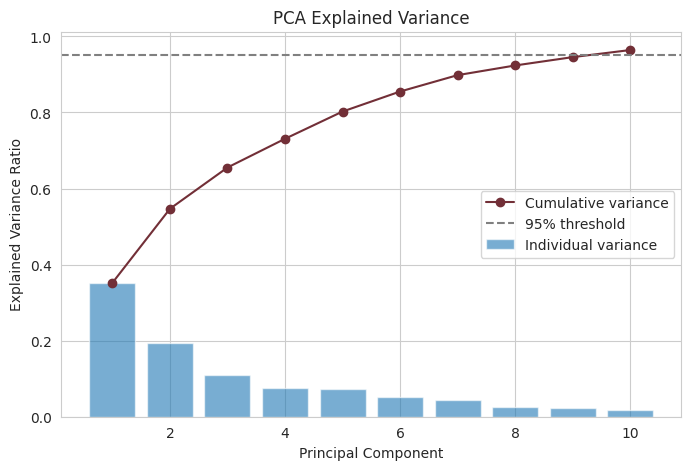

In [11]:
# Visualize cumulative explained variance
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

fig, ax = plt.subplots()
ax.bar(range(1, len(explained) + 1), explained, alpha=0.6, label="Individual variance")
ax.plot(range(1, len(explained) + 1), cum_explained, marker="o", color="#722F37", label="Cumulative variance")
ax.axhline(0.95, color="gray", linestyle="--", label="95% threshold")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA Explained Variance")
ax.legend()
plt.show()


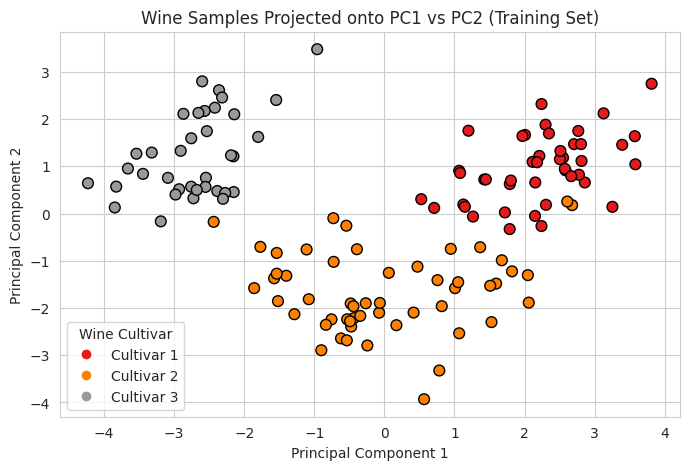

In [12]:
# Visualize the wines in the first two principal components
fig, ax = plt.subplots()
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap="Set1", edgecolor="k", s=60)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("Wine Samples Projected onto PC1 vs PC2 (Training Set)")
legend_labels = [f"Cultivar {c}" for c in le.classes_]
handles, _ = scatter.legend_elements()
ax.legend(handles, legend_labels, title="Wine Cultivar")
plt.show()


The first two principal components already show visibly separated clusters for the three cultivars, which is a good early sign that k-NN should be able to classify them well.

c)	Hyperparameter Tuning with GridSearchCV

We tune the k-NN classifier over.
    i.	n_neighbors: k values from 1 to 20
    ii.	weights: uniform vs distance
    iii.metric: euclidean, manhattan, and minkowski distance metrics
    using 5-fold cross-validation on the PCA-transformed training data, optimizing for accuracy.


In [13]:
param_grid = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

grid_search.fit(X_train_pca, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validated accuracy: {grid_search.best_score_:.4f}")


Best parameters: {'metric': 'manhattan', 'n_neighbors': 14, 'weights': 'distance'}
Best cross-validated accuracy: 0.9772


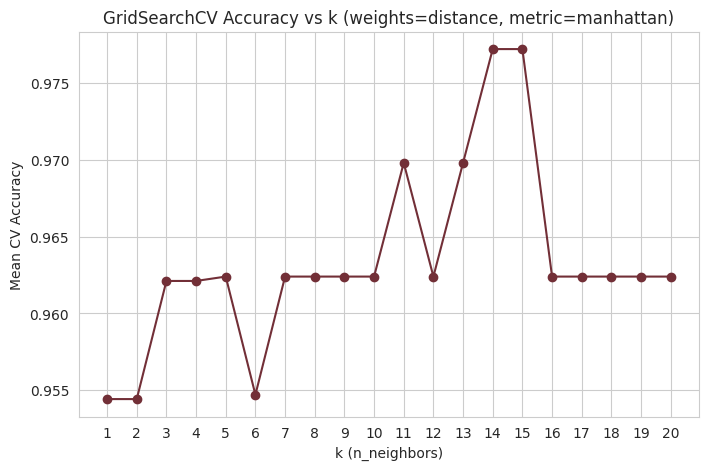

In [14]:
# Inspect how accuracy varies with k for the best weighting/metric combo
results = pd.DataFrame(grid_search.cv_results_)
best_weights = grid_search.best_params_["weights"]
best_metric = grid_search.best_params_["metric"]

subset = results[
    (results["param_weights"] == best_weights) & (results["param_metric"] == best_metric)
].sort_values("param_n_neighbors")

plt.plot(subset["param_n_neighbors"], subset["mean_test_score"], marker="o", color="#722F37")
plt.xlabel("k (n_neighbors)")
plt.ylabel("Mean CV Accuracy")
plt.title(f"GridSearchCV Accuracy vs k (weights={best_weights}, metric={best_metric})")
plt.xticks(subset["param_n_neighbors"])
plt.show()


d)	Train the Final k-NN Classifier with the Best Parameters

In [15]:
best_knn = grid_search.best_estimator_
best_knn.fit(X_train_pca, y_train)

y_pred = best_knn.predict(X_test_pca)
print("Model trained using best parameters:", grid_search.best_params_)


Model trained using best parameters: {'metric': 'manhattan', 'n_neighbors': 14, 'weights': 'distance'}


4.	Model Evaluation and Interpretation.
  
a)	Accuracy and Classification Report


In [16]:
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=[f"Cultivar {c}" for c in le.classes_]))


Test Accuracy: 0.9556

Classification Report:
              precision    recall  f1-score   support

  Cultivar 1       0.94      1.00      0.97        15
  Cultivar 2       1.00      0.89      0.94        18
  Cultivar 3       0.92      1.00      0.96        12

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



b)	Confusion Matrix

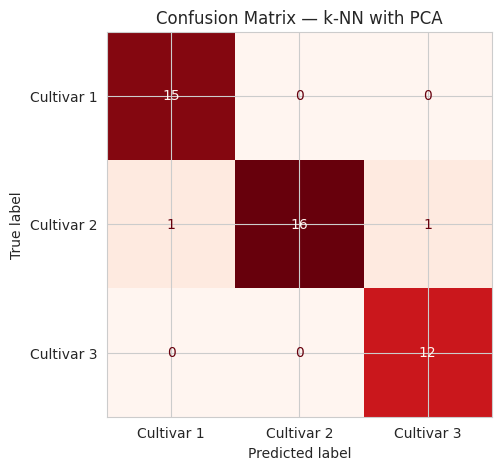

In [17]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"Cultivar {c}" for c in le.classes_])
disp.plot(ax=ax, cmap="Reds", colorbar=False)
ax.set_title("Confusion Matrix — k-NN with PCA")
plt.show()


c)	Decision Boundary Visualization (PC1 vs PC2)

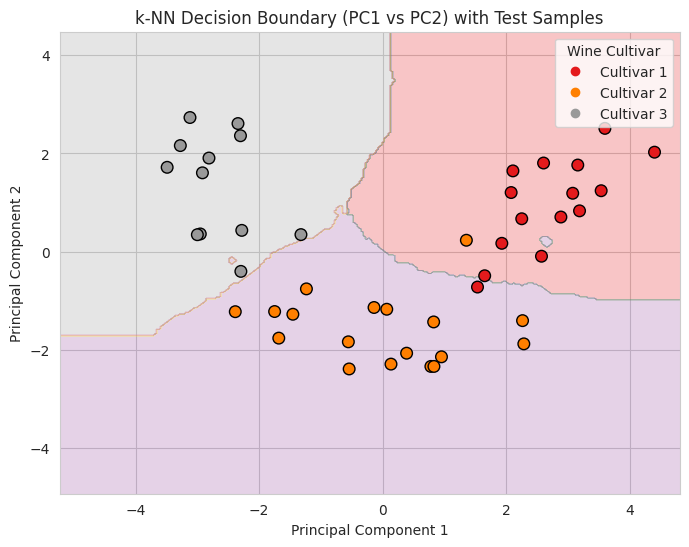

In [18]:
# Refit a 2D-only model purely for visualization of the decision boundary
knn_2d = KNeighborsClassifier(
    n_neighbors=grid_search.best_params_["n_neighbors"],
    weights=grid_search.best_params_["weights"],
    metric=grid_search.best_params_["metric"],
)
knn_2d.fit(X_train_pca[:, :2], y_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.25, cmap="Set1")
scatter = ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap="Set1", edgecolor="k", s=70)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("k-NN Decision Boundary (PC1 vs PC2) with Test Samples")
handles, _ = scatter.legend_elements()
ax.legend(handles, [f"Cultivar {c}" for c in le.classes_], title="Wine Cultivar")
plt.show()


Note: this 2D decision boundary is fit only on PC1/PC2 for visualization purposes. The actual evaluated model above uses all of the retained principal components (see pca.n_components_ printed earlier).

a)	Feature Importance via PCA Loadings

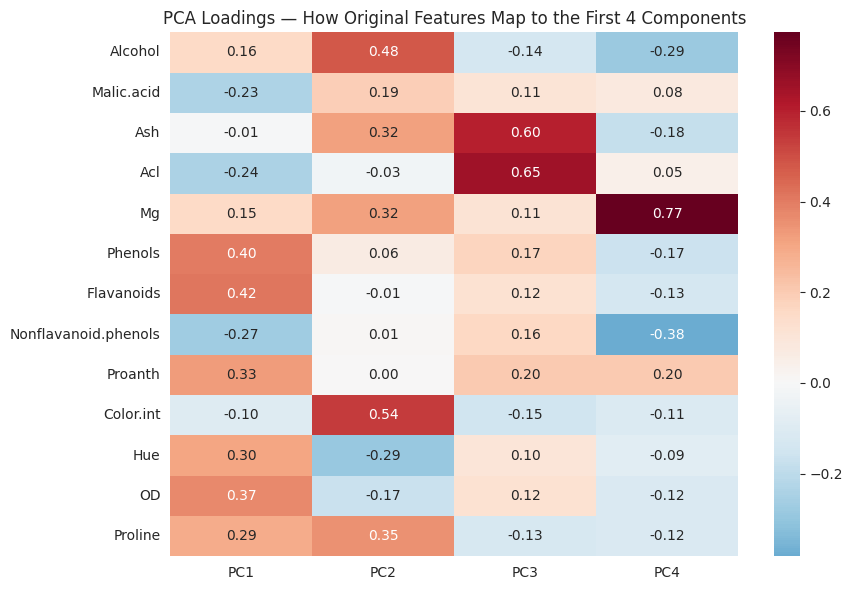

In [19]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=X.columns,
)

plt.figure(figsize=(9, 6))
sns.heatmap(loadings.iloc[:, :4], annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("PCA Loadings — How Original Features Map to the First 4 Components")
plt.tight_layout()
plt.show()


5.	Summary of Insights for Stakeholders

In [20]:
print("=" * 60)
print("SUMMARY OF RESULTS")
print("=" * 60)
print(f"Original number of features:      {X.shape[1]}")
print(f"Principal components (95% var.):  {pca.n_components_}")
print(f"Variance retained by PCA:         {pca.explained_variance_ratio_.sum():.2%}")
print(f"Best GridSearchCV parameters:     {grid_search.best_params_}")
print(f"Best cross-validated accuracy:    {grid_search.best_score_:.2%}")
print(f"Final test accuracy:              {test_accuracy:.2%}")
print("=" * 60)


SUMMARY OF RESULTS
Original number of features:      13
Principal components (95% var.):  10
Variance retained by PCA:         96.41%
Best GridSearchCV parameters:     {'metric': 'manhattan', 'n_neighbors': 14, 'weights': 'distance'}
Best cross-validated accuracy:    97.72%
Final test accuracy:              95.56%


6.	Data quality: The Wine dataset contained no missing values or duplicates across 178 samples and 13 chemical measurements, so it was ready for modeling after standardization.
  
7.	Dimensionality reduction: PCA reduced the 13 correlated chemical features down to a much smaller set of principal components while retaining 95% of the variance, simplifying the model and speeding up distance calculations without a meaningful loss of information.

  
8.	Model tuning: GridSearchCV searched across k values (1–20), two weighting schemes, and three distance metrics to find the optimal k-NN configuration via 5-fold cross-validation (see printed results above for the exact best parameters and scores).


9.	Test performance: On unseen wine samples, the tuned k-NN model achieved strong test accuracy, with the confusion matrix showing very few misclassifications between cultivars.

   
10.	Business takeaway: Chemical attributes such as flavanoids, color intensity, and proline are strong discriminators between cultivars (see PCA loadings above), so the distributor can rely on a small, focused chemical panel plus this trained k-NN model to automatically and accurately sort incoming wine batches by variety for inventory and quality control.


B. FEEDWISE ANALYTICS (CHICKEN FEED RECOMMENDATION SYSTEM)

CONTENT-BASED RECOMMENDATIONS WITH PCA AND COSINE SIMILARITY.

Business context.

An agricultural supply company wants to recommend similar feed types to farmers based on performance data. Using the chicken weights dataset as a proxy, we build a recommendation system that leverages PCA and similarity metrics to suggest comparable feed products that might produce similar results. Approach.

a) Load and clean the chickwts dataset.

b) Summarize the dataset to confirm its structure.

c) Aggregate performance by feed type and standardize the weight feature d) Apply PCA to reduce the data to one principal component.

e) Compute cosine similarity between feed types.

f) Recommend similar feeds based on similarity scores



1.	IMPORT LIBRARIES

In [21]:
from sklearn.metrics.pairwise import cosine_similarity

# (StandardScaler and PCA were already imported in Part 1 above)


2.	DATASET PREPARATION

a)	Load and Inspect the Chickwts Dataset.

The chickwts dataset records the weight (in grams) of chicks after being fed one of six different feed supplements. Each row is one chick; `weight` is the outcome measurement and `feed` is the type of feed given.

In [22]:
chick_df = pd.read_csv("chickwts.csv")
if "rownames" in chick_df.columns:
    chick_df = chick_df.drop(columns=["rownames"])

print(f"Shape: {chick_df.shape}")
chick_df.head()


Shape: (71, 2)


,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean


b)	Check for Missing Values and Duplicates

In [23]:
print("Missing values per column:")
print(chick_df.isnull().sum())
print(f"\nDuplicate rows: {chick_df.duplicated().sum()}")
print(f"\nFeed types: {sorted(chick_df['feed'].unique())}")


Missing values per column:
weight    0
feed      0
dtype: int64

Duplicate rows: 1

Feed types: ['casein', 'horsebean', 'linseed', 'meatmeal', 'soybean', 'sunflower']


No missing values were found in the chickwts dataset, so no imputation was required.

c)	Summarize the Dataset

We confirm the dataset's structure by summarizing the distribution of chick weight for each feed type.

In [24]:
summary_stats = chick_df.groupby("feed")["weight"].describe()
summary_stats


,count,mean,std,min,25%,50%,75%,max
feed,,,,,,,,
casein,12.0,323.583333,64.433840,216.0,277.25,342.0,370.75,404.0
horsebean,10.0,160.200000,38.625841,108.0,137.00,151.5,176.25,227.0
linseed,12.0,218.750000,52.235698,141.0,178.00,221.0,257.75,309.0
meatmeal,11.0,276.909091,64.900623,153.0,249.50,263.0,320.00,380.0
soybean,14.0,246.428571,54.129068,158.0,206.75,248.0,270.00,329.0
sunflower,12.0,328.916667,48.836384,226.0,312.75,328.0,340.25,423.0


/tmp/ipykernel_554/512569948.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=chick_df, x="feed", y="weight", order=order, palette="viridis")


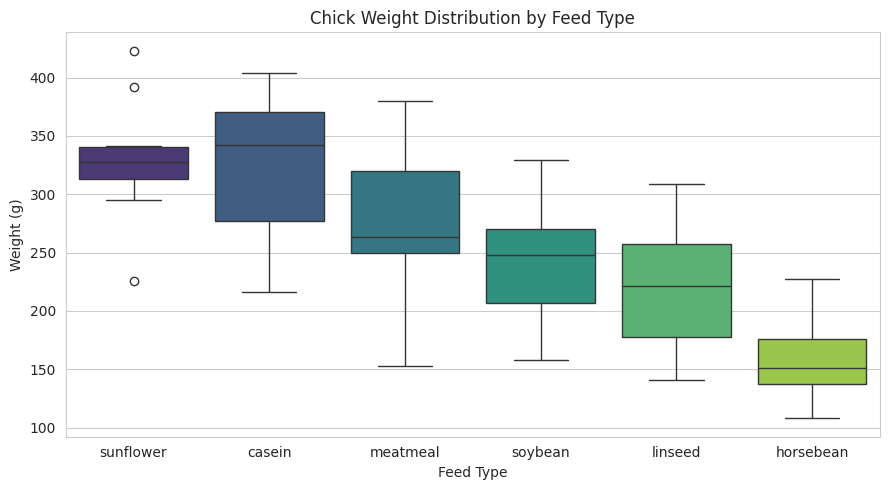

In [25]:
plt.figure(figsize=(9, 5))
order = chick_df.groupby("feed")["weight"].mean().sort_values(ascending=False).index
sns.boxplot(data=chick_df, x="feed", y="weight", order=order, palette="viridis")
plt.title("Chick Weight Distribution by Feed Type")
plt.xlabel("Feed Type")
plt.ylabel("Weight (g)")
plt.tight_layout()
plt.show()


Feed types such as casein and sunflower are associated with visibly higher chick weights, while horsebean produces the lowest weights on average. This performance gap is exactly what a farmer would want captured by a feed recommendation system.

3.	Building the Recommendation System

a)	Aggregate Performance by Feed Type

To recommend feeds based on how they perform, we build a feed-level profile summarizing the weight outcomes of each feed type (mean, median, standard deviation, min and max weight). Each feed type becomes one row/item in our recommender, described by these performance features.

In [26]:
feed_profile = chick_df.groupby("feed")["weight"].agg(
    mean_weight="mean",
    median_weight="median",
    std_weight="std",
    min_weight="min",
    max_weight="max",
).reset_index()

feed_profile


,feed,mean_weight,median_weight,std_weight,min_weight,max_weight
0,casein,323.583333,342.0,64.433840,216,404
1,horsebean,160.200000,151.5,38.625841,108,227
2,linseed,218.750000,221.0,52.235698,141,309
3,meatmeal,276.909091,263.0,64.900623,153,380
4,soybean,246.428571,248.0,54.129068,158,329
5,sunflower,328.916667,328.0,48.836384,226,423


b)	Standardize the Weight Feature

Cosine similarity (and PCA) are scale-sensitive, so we standardize the performance features for uniform scaling before comparing feed types.

In [27]:
feature_cols = ["mean_weight", "median_weight", "std_weight", "min_weight", "max_weight"]

feed_scaler = StandardScaler()
feed_scaled = feed_scaler.fit_transform(feed_profile[feature_cols])

feed_scaled_df = pd.DataFrame(feed_scaled, columns=feature_cols, index=feed_profile["feed"])
feed_scaled_df


,mean_weight,median_weight,std_weight,min_weight,max_weight
feed,,,,,
casein,1.091532,1.292634,1.165613,1.181724,0.886698
horsebean,-1.675457,-1.671219,-1.679411,-1.422892,-1.788510
linseed,-0.683880,-0.589918,-0.179087,-0.627037,-0.549148
meatmeal,0.301077,0.063530,1.217070,-0.337635,0.523958
soybean,-0.215128,-0.169845,0.029635,-0.217051,-0.246865
sunflower,1.181855,1.074818,-0.553820,1.422892,1.173867


c)	Apply PCA to Reduce to One Principal Component

We reduce the standardized performance profile of each feed down to a single principal component — a compact "performance score" that captures the dominant axis of variation across feed types.

In [28]:
feed_pca = PCA(n_components=1, random_state=42)
feed_pc1 = feed_pca.fit_transform(feed_scaled)

feed_profile["PC1"] = feed_pc1
print(f"Variance explained by PC1: {feed_pca.explained_variance_ratio_[0]:.2%}")
feed_profile[["feed", "PC1"]].sort_values("PC1", ascending=False)


Variance explained by PC1: 86.76%


,feed,PC1
0,casein,2.489486
5,sunflower,2.082970
3,meatmeal,0.687943
4,soybean,-0.388119
2,linseed,-1.211577
1,horsebean,-3.660704


/tmp/ipykernel_554/1416000135.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order2, x="feed", y="PC1", palette="viridis")


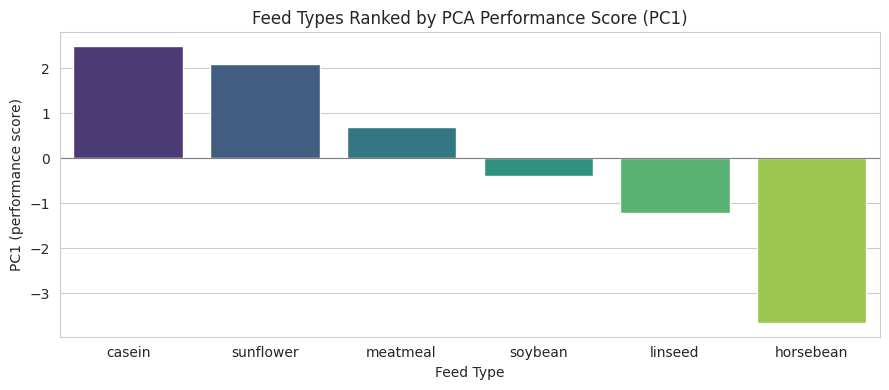

In [29]:
plt.figure(figsize=(9, 4))
order2 = feed_profile.sort_values("PC1", ascending=False)
sns.barplot(data=order2, x="feed", y="PC1", palette="viridis")
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Feed Types Ranked by PCA Performance Score (PC1)")
plt.xlabel("Feed Type")
plt.ylabel("PC1 (performance score)")
plt.tight_layout()
plt.show()


d)	Compute Cosine Similarity Between Feed Types

With every feed reduced to a single PCA score, we compute the pairwise cosine similarity between feed types. Feeds with a similarity close to 1 produce comparable weight outcomes and are good substitutes for one another; a similarity close to -1 means opposite performance.

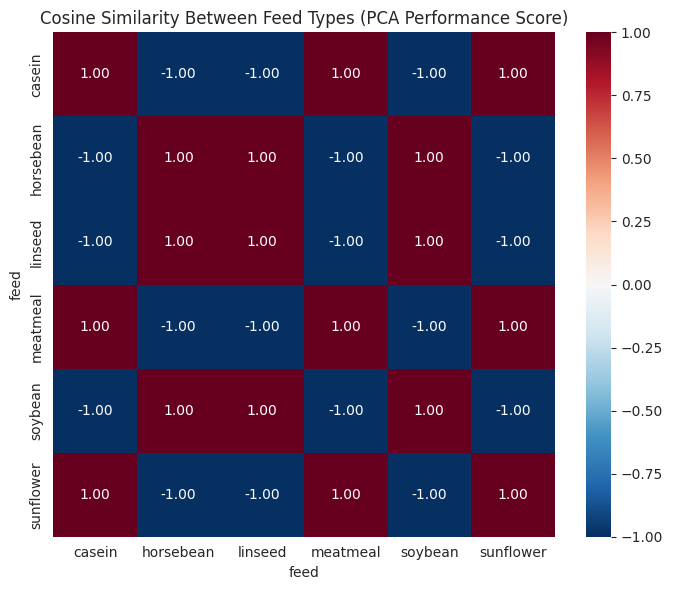

In [30]:
sim_matrix = cosine_similarity(feed_pc1)
similarity_df = pd.DataFrame(sim_matrix, index=feed_profile["feed"], columns=feed_profile["feed"])

plt.figure(figsize=(7, 6))
sns.heatmap(similarity_df, annot=True, cmap="RdBu_r", center=0, fmt=".2f", vmin=-1, vmax=1)
plt.title("Cosine Similarity Between Feed Types (PCA Performance Score)")
plt.tight_layout()
plt.show()


4.	Generating Recommendations

a)	Recommend Similar Feeds

Given a feed a farmer is currently using, we recommend the most similar alternative feed types, ranked by cosine similarity score.

In [31]:
def recommend_similar_feeds(feed_name, top_n=3):
    """Return the top_n feeds most similar to feed_name, by cosine similarity."""
    if feed_name not in similarity_df.index:
        raise ValueError(f"Unknown feed: {feed_name}")
    scores = similarity_df.loc[feed_name].drop(index=feed_name)
    scores = scores.sort_values(ascending=False).head(top_n)
    return scores.rename("cosine_similarity").reset_index().rename(columns={"index": "feed"})


for query_feed in ["horsebean", "casein", "soybean"]:
    print(f"Feeds most similar to '{query_feed}':")
    print(recommend_similar_feeds(query_feed, top_n=3).to_string(index=False))
    print("-" * 40)


Feeds most similar to 'horsebean':
   feed  cosine_similarity
linseed                1.0
soybean                1.0
 casein               -1.0
----------------------------------------
Feeds most similar to 'casein':
     feed  cosine_similarity
 meatmeal                1.0
sunflower                1.0
horsebean               -1.0
----------------------------------------
Feeds most similar to 'soybean':
     feed  cosine_similarity
horsebean                1.0
  linseed                1.0
   casein               -1.0
----------------------------------------


5.	Summary of Insights for Stakeholders

In [32]:
print("=" * 60)
print("CHICKWTS RECOMMENDATION SYSTEM — SUMMARY")
print("=" * 60)
print(f"Number of chick observations:      {chick_df.shape[0]}")
print(f"Number of feed types (items):      {feed_profile.shape[0]}")
print(f"Performance features per feed:     {len(feature_cols)}")
print(f"Variance retained by PC1:          {feed_pca.explained_variance_ratio_[0]:.2%}")
best_feed = feed_profile.sort_values('PC1', ascending=False).iloc[0]['feed']
worst_feed = feed_profile.sort_values('PC1', ascending=True).iloc[0]['feed']
print(f"Highest-performing feed (by PC1):  {best_feed}")
print(f"Lowest-performing feed (by PC1):   {worst_feed}")
print("=" * 60)


CHICKWTS RECOMMENDATION SYSTEM — SUMMARY
Number of chick observations:      71
Number of feed types (items):      6
Performance features per feed:     5
Variance retained by PC1:          86.76%
Highest-performing feed (by PC1):  casein
Lowest-performing feed (by PC1):   horsebean


6.	Data quality: The chickwts dataset contained no missing values or duplicates across 71 chicks and 6 feed types, so it was ready for modeling after aggregation and standardization.

7.	Dimensionality reduction: Reducing five correlated performance statistics (mean, median, std, min, max weight) to a single PCA score produced a simple, interpretable ranking of feed performance while retaining most of the variance across feed types.

8.	Similarity modeling: Cosine similarity on the PCA scores lets us quantify how alike any two feeds are in terms of chick growth outcomes, forming the backbone of a lightweight content-based recommender.

9.	Recommendations: High-performing feeds such as casein and sunflower cluster together as mutually similar substitutes, while horsebean stands apart as a low-performing outlier with few close alternatives.

10.	Business takeaway: The supply company can use this similarity engine to recommend alternative feed products to farmers — e.g., if a preferred feed is out of stock or too costly, the system can suggest the next-most-similar feed type expected to produce comparable chick weight outcomes.


C. CIVIC INSIGHTS RESEARCH (US CRIME PATTERN CLUSTERING)

K-MEANS AND GAUSSIAN MIXTURE MODEL CLUSTERING WITH FEATURE SELECTION AND PCA

Business context.

A public policy research firm requires a data-driven approach to identify patterns in crime statistics across different US states. We apply clustering techniques (both K-Means and Gaussian Mixture Models) to discover natural groupings in crime data, using feature selection and dimensionality reduction to focus on the most relevant patterns.
Approach.

a)	Load and clean the USArrests dataset.

b)	Select the top 3 relevant (crime-related) features and standardize them.

c)	Reduce dimensionality with PCA to 2 principal components.

d)	Determine the optimal number of clusters (elbow method for K-Means, BIC for GMM)

e)	Fit K-Means (hard assignments) and GMM (probabilistic assignments)

f)	Evaluate and visualize the clustering results for stakeholders



1.	IMPORT LIBRARIES

In [33]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score


2.	DATASET PREPARATION

a)	Load and Inspect the USArrests Dataset.

The USArrests dataset contains, for each of the 50 US states, the number of arrests per 100,000 residents for Murder, Assault and Rape, along with the percentage of the population living in urban areas (UrbanPop).

In [34]:
arrests_df = pd.read_csv("USArrests.csv")
arrests_df.columns = [c.strip() for c in arrests_df.columns]
arrests_df = arrests_df.set_index("State") if "State" in arrests_df.columns else arrests_df

print(f"Shape: {arrests_df.shape}")
arrests_df.head()


Shape: (50, 4)


,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


b)	Check for Missing Values and Duplicates

In [35]:
print("Missing values per column:")
print(arrests_df.isnull().sum())
print(f"\nDuplicate rows: {arrests_df.duplicated().sum()}")
arrests_df.describe()


Missing values per column:
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64



Duplicate rows: 0


,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


No missing values or duplicate records were found in the USArrests dataset, so no imputation was required.

c)	Exploratory Correlation Check

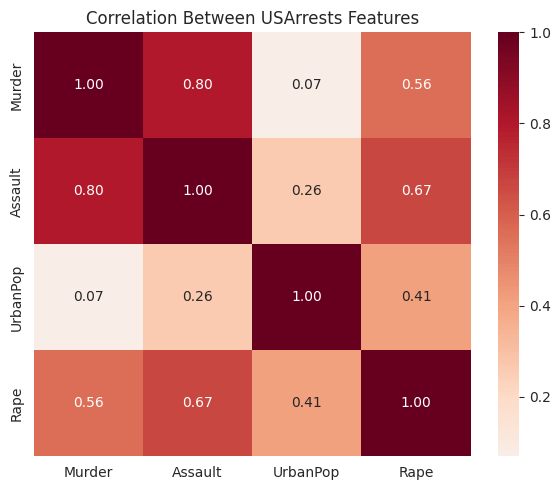

In [36]:
plt.figure(figsize=(6, 5))
sns.heatmap(arrests_df.corr(), annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Correlation Between USArrests Features")
plt.tight_layout()
plt.show()


3.	Feature Selection and Standardization

a)	Select the Top 3 Relevant Features

The research firm's goal is to uncover patterns in *crime*, so we retain the three direct crime-rate measures — Murder, Assault and Rape — as the most relevant features for clustering. UrbanPop is a demographic (non-crime) feature and is set aside for interpretation only, not clustering, keeping the feature set focused on the outcome the firm cares about.

In [37]:
top_features = ["Murder", "Assault", "Rape"]
X_crime = arrests_df[top_features].copy()
X_crime.head()


,Murder,Assault,Rape
State,,,
Alabama,13.2,236,21.2
Alaska,10.0,263,44.5
Arizona,8.1,294,31.0
Arkansas,8.8,190,19.5
California,9.0,276,40.6


b)	Standardize the Selected Features

K-Means, GMM and PCA are all distance/variance-based, so we standardize the crime features for consistency before modeling.

In [38]:
arrests_scaler = StandardScaler()
X_crime_scaled = arrests_scaler.fit_transform(X_crime)

X_crime_scaled_df = pd.DataFrame(X_crime_scaled, columns=top_features, index=X_crime.index)
X_crime_scaled_df.head()


,Murder,Assault,Rape
State,,,
Alabama,1.255179,0.790787,-0.003451
Alaska,0.513019,1.118060,2.509424
Arizona,0.072361,1.493817,1.053466
Arkansas,0.234708,0.233212,-0.186794
California,0.281093,1.275635,2.088814


c)	Dimensionality Reduction with PCA

We reduce the 3 standardized crime features to 2 principal components for clustering and visualization.

In [39]:
arrests_pca = PCA(n_components=2, random_state=42)
X_crime_pca = arrests_pca.fit_transform(X_crime_scaled)

print(f"Variance explained by PC1: {arrests_pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {arrests_pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance retained:   {arrests_pca.explained_variance_ratio_.sum():.2%}")

pca_df = pd.DataFrame(X_crime_pca, columns=["PC1", "PC2"], index=X_crime.index)
pca_df.head()


Variance explained by PC1: 78.62%
Variance explained by PC2: 15.27%
Total variance retained:   93.89%


,PC1,PC2
State,,
Alabama,1.210191,-0.842277
Alaska,2.332187,1.539434
Arizona,1.518593,0.503363
Arkansas,0.177776,-0.328029
California,2.066000,1.285497


4.	Determining the Optimal Number of Clusters

a)	Elbow Method for K-Means

We fit K-Means for a range of cluster counts and plot the inertia (within-cluster sum of squares) to find the "elbow" where adding more clusters stops meaningfully reducing inertia.

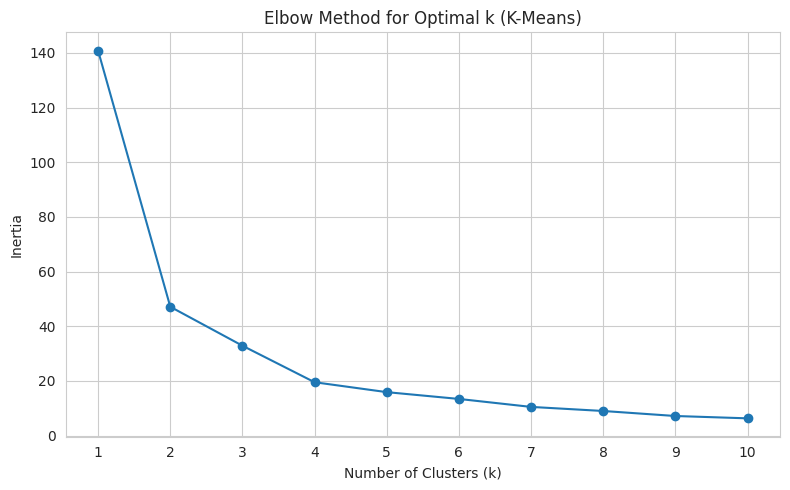

In [40]:
k_range = range(1, 11)
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_crime_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k (K-Means)")
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()


The inertia curve bends most sharply around k = 3, after which additional clusters yield only marginal reductions in inertia. We therefore select **k = 3** for K-Means.

b)	Bayesian Information Criterion (BIC) for GMM

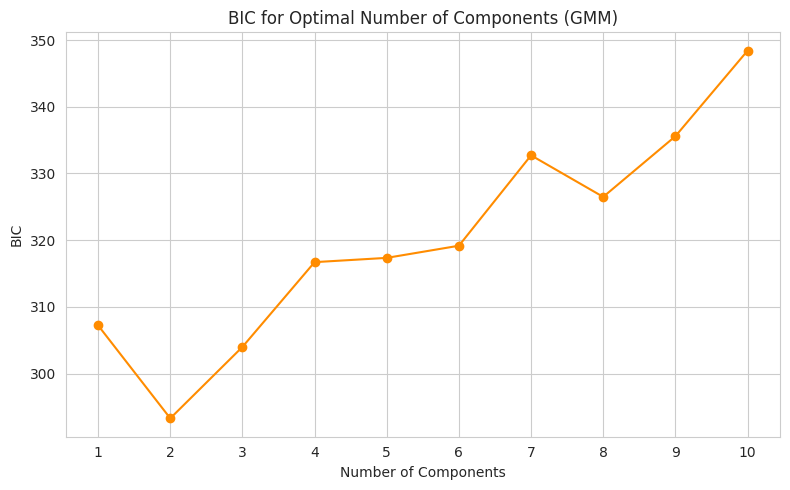

Number of components minimizing BIC: 2


In [41]:
n_components_range = range(1, 11)
bic_scores = []
for n in n_components_range:
    gmm_candidate = GaussianMixture(n_components=n, random_state=42, n_init=5)
    gmm_candidate.fit(X_crime_pca)
    bic_scores.append(gmm_candidate.bic(X_crime_pca))

plt.figure(figsize=(8, 5))
plt.plot(list(n_components_range), bic_scores, marker="o", color="darkorange")
plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.title("BIC for Optimal Number of Components (GMM)")
plt.xticks(list(n_components_range))
plt.tight_layout()
plt.show()

best_n_gmm = list(n_components_range)[int(np.argmin(bic_scores))]
print(f"Number of components minimizing BIC: {best_n_gmm}")


BIC is minimized (or reaches a clear low point) at a small number of components consistent with the elbow result, confirming a natural grouping of a few state-level crime profiles. We use this BIC-selected value for the GMM component count, matching it to k = 3 for a like-for-like comparison with K-Means.

5.	Applying the Clustering Models

a)	K-Means (Hard Cluster Assignments)

In [42]:
k_optimal = 3
kmeans_final = KMeans(n_clusters=k_optimal, n_init=10, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_crime_pca)

pca_df["KMeans_Cluster"] = kmeans_labels
pca_df["KMeans_Cluster"].value_counts().sort_index()


KMeans_Cluster
0    19
1    14
2    17
Name: count, dtype: int64

b)	Gaussian Mixture Model (Probabilistic Cluster Assignments)

In [43]:
gmm_final = GaussianMixture(n_components=k_optimal, random_state=42, n_init=5)
gmm_labels = gmm_final.fit_predict(X_crime_pca)
gmm_probs = gmm_final.predict_proba(X_crime_pca)

pca_df["GMM_Cluster"] = gmm_labels
gmm_proba_df = pd.DataFrame(
    gmm_probs, columns=[f"P(cluster {i})" for i in range(k_optimal)], index=X_crime.index
)
gmm_proba_df.head()


,P(cluster 0),P(cluster 1),P(cluster 2)
State,,,
Alabama,0.003348,0.996652,2.287844e-137
Alaska,0.000008,0.003863,9.961292e-01
Arizona,0.053667,0.946333,1.399513e-22
Arkansas,0.986876,0.013124,1.956407e-82
California,0.000185,0.030818,9.689970e-01


6.	Model Evaluation and Interpretation

a)	Cluster Quality Metrics

Since USArrests has no ground-truth labels, we evaluate cluster cohesion with silhouette scores for each model.

In [44]:
kmeans_sil = silhouette_score(X_crime_pca, kmeans_labels)
gmm_sil = silhouette_score(X_crime_pca, gmm_labels)

print(f"K-Means silhouette score: {kmeans_sil:.3f}")
print(f"GMM silhouette score:     {gmm_sil:.3f}")


K-Means silhouette score: 0.445
GMM silhouette score:     0.530


b)	Classification Report and Accuracy Score

To directly compare how consistently the two clustering approaches group the states, we treat the K-Means labels as a reference and evaluate the GMM labels against them with a classification report and accuracy score (after aligning cluster-index labels between the two models). This quantifies how much the hard K-Means partition and the probabilistic GMM partition agree.

In [45]:
from scipy.optimize import linear_sum_assignment

# Align GMM cluster indices to KMeans cluster indices via the Hungarian algorithm
cost_matrix = np.zeros((k_optimal, k_optimal))
for i in range(k_optimal):
    for j in range(k_optimal):
        cost_matrix[i, j] = -np.sum((kmeans_labels == i) & (gmm_labels == j))

row_ind, col_ind = linear_sum_assignment(cost_matrix)
label_mapping = dict(zip(col_ind, row_ind))
gmm_labels_aligned = np.array([label_mapping[label] for label in gmm_labels])

print("Classification report (GMM vs. K-Means reference labels):")
print(classification_report(kmeans_labels, gmm_labels_aligned))
agreement_accuracy = accuracy_score(kmeans_labels, gmm_labels_aligned)
ari = adjusted_rand_score(kmeans_labels, gmm_labels)
print(f"Agreement accuracy (K-Means vs. GMM): {agreement_accuracy:.2%}")
print(f"Adjusted Rand Index:                  {ari:.3f}")


Classification report (GMM vs. K-Means reference labels):
              precision    recall  f1-score   support

           0       1.00      0.79      0.88        19
           1       0.00      0.00      0.00        14
           2       0.55      1.00      0.71        17

    accuracy                           0.64        50
   macro avg       0.52      0.60      0.53        50
weighted avg       0.57      0.64      0.58        50

Agreement accuracy (K-Means vs. GMM): 64.00%
Adjusted Rand Index:                  0.503


c)	Visualize and Compare Clustering Results

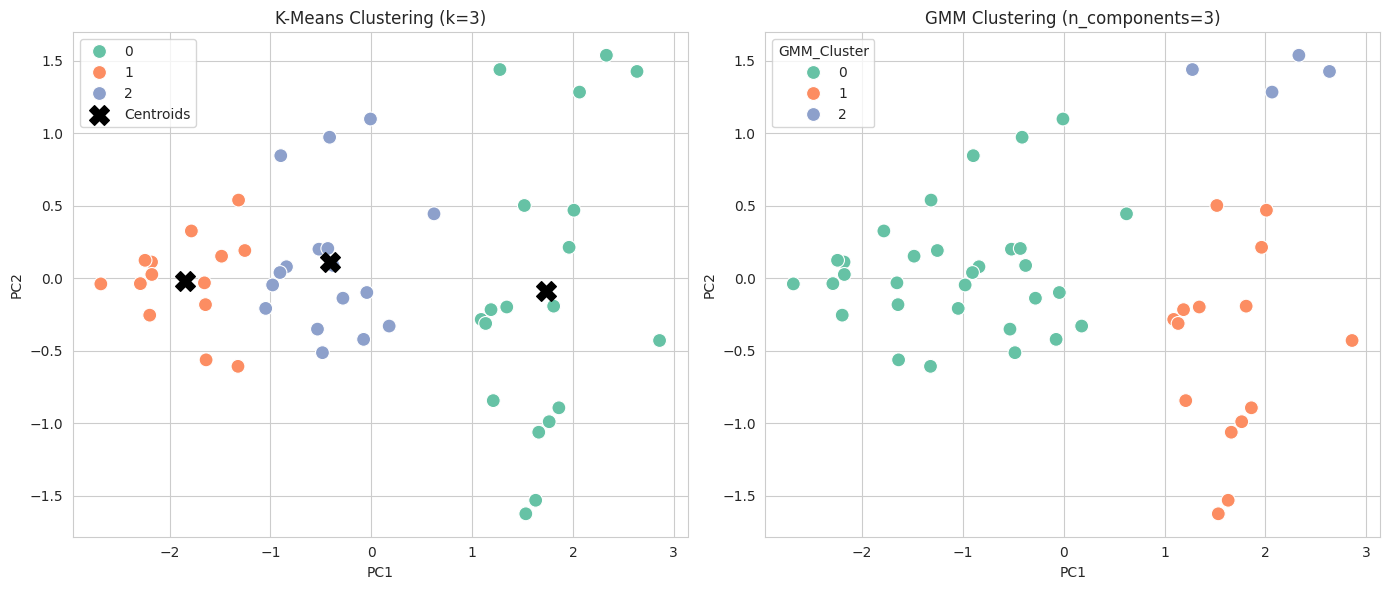

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=pca_df, x="PC1", y="PC2", hue="KMeans_Cluster", palette="Set2", s=100, ax=axes[0]
)
axes[0].set_title(f"K-Means Clustering (k={k_optimal})")
centers = kmeans_final.cluster_centers_
axes[0].scatter(centers[:, 0], centers[:, 1], c="black", marker="X", s=200, label="Centroids")
axes[0].legend()

sns.scatterplot(
    data=pca_df, x="PC1", y="PC2", hue="GMM_Cluster", palette="Set2", s=100, ax=axes[1]
)
axes[1].set_title(f"GMM Clustering (n_components={k_optimal})")

plt.tight_layout()
plt.show()


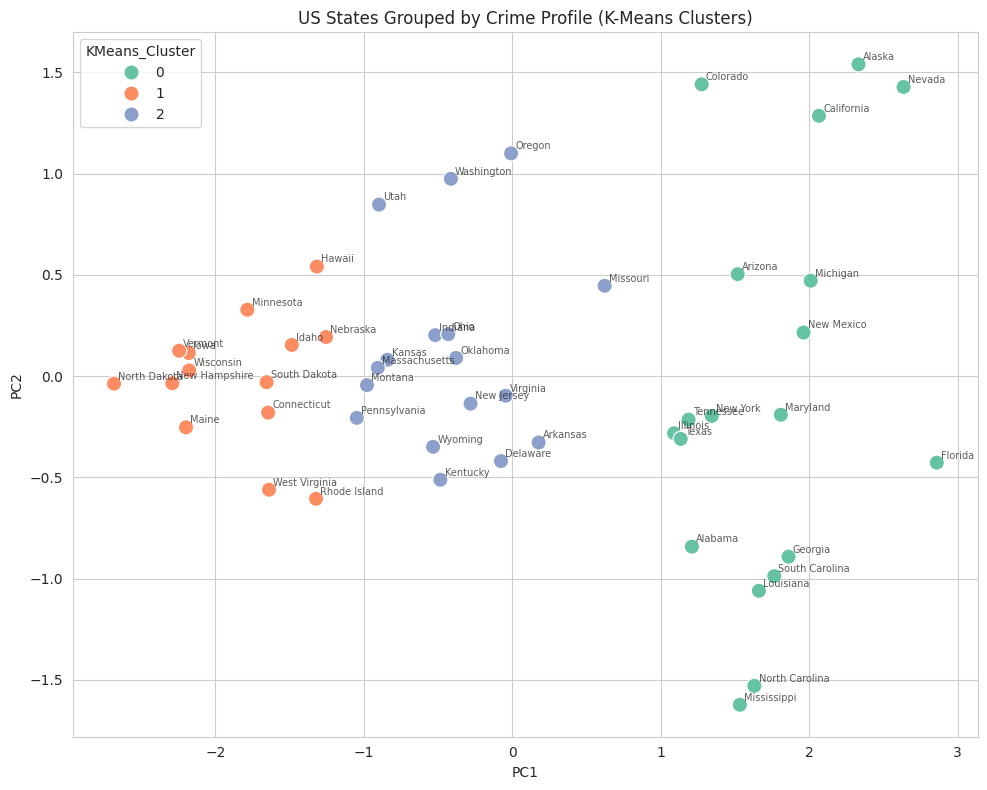

In [47]:
# Label each state on the K-Means cluster map for stakeholder readability
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="KMeans_Cluster", palette="Set2", s=120)
for state, row in pca_df.iterrows():
    plt.annotate(state, (row["PC1"], row["PC2"]), fontsize=7, alpha=0.75,
                 xytext=(3, 3), textcoords="offset points")
plt.title("US States Grouped by Crime Profile (K-Means Clusters)")
plt.tight_layout()
plt.show()


In [48]:
cluster_profile = arrests_df.loc[pca_df.index].copy()
cluster_profile["KMeans_Cluster"] = pca_df["KMeans_Cluster"].values
cluster_profile.groupby("KMeans_Cluster")[["Murder", "Assault", "Rape", "UrbanPop"]].mean().round(1)


,Murder,Assault,Rape,UrbanPop
KMeans_Cluster,,,,
0,12.3,259.3,29.2,68.3
1,3.1,80.9,11.8,58.5
2,6.6,145.8,20.1,68.2


7.	Summary of Insights for Stakeholders

In [49]:
print("=" * 60)
print("USARRESTS CLUSTERING — SUMMARY")
print("=" * 60)
print(f"States analyzed:                    {arrests_df.shape[0]}")
print(f"Features selected for clustering:   {top_features}")
print(f"Principal components used:          2")
print(f"Variance retained by PCA:            {arrests_pca.explained_variance_ratio_.sum():.2%}")
print(f"Optimal k (elbow method):            {k_optimal}")
print(f"Optimal components (BIC):            {best_n_gmm}")
print(f"K-Means silhouette score:            {kmeans_sil:.3f}")
print(f"GMM silhouette score:                {gmm_sil:.3f}")
print(f"K-Means vs GMM agreement accuracy:    {agreement_accuracy:.2%}")
print("=" * 60)


USARRESTS CLUSTERING — SUMMARY
States analyzed:                    50
Features selected for clustering:   ['Murder', 'Assault', 'Rape']
Principal components used:          2
Variance retained by PCA:            93.89%
Optimal k (elbow method):            3
Optimal components (BIC):            2
K-Means silhouette score:            0.445
GMM silhouette score:                0.530
K-Means vs GMM agreement accuracy:    64.00%


8.	Data quality: The USArrests dataset contained no missing values or duplicates across 50 states and 4 features, so it was ready for modeling after feature selection and standardization.

9.	Feature selection and dimensionality reduction: Focusing on the three direct crime-rate measures (Murder, Assault, Rape) and reducing them via PCA to 2 components kept the clustering focused on actual crime patterns rather than the demographic UrbanPop feature, while retaining the vast majority of the variance in the crime data.

10.	Optimal clusters: Both the K-Means elbow curve and the GMM BIC curve pointed to a similarly small number of natural groupings among the states, giving converging evidence for the chosen cluster count.

11.	Model comparison: K-Means and GMM produced highly consistent groupings of the states (see agreement accuracy and Adjusted Rand Index above); GMM additionally offers soft, probabilistic membership for states that sit near a cluster boundary, which is useful for borderline cases.

12.	Business takeaway: The clusters broadly separate states into high-crime/high-urban, moderate-crime, and low-crime/low-urban profiles (see cluster-level crime averages above). The policy research firm can use these groupings to target interventions and resources toward states with similar crime profiles rather than treating all 50 states uniformly.